# Breast Cancer Diagnosis with Decision Trees
### Binary Classification | Decision Tree | Scikit-learn

---
This notebook uses the **Breast Cancer Wisconsin (Diagnostic) Dataset** for a binary classification task.


**Objectives:**
- Train a baseline Decision Tree classifier and evaluate its tendency to overfit
- Apply GridSearchCV with cross-validation to tune depth and split constraints
- Interpret the final model through tree visualization and feature importance analysis


## 1. Environment Setup & Dependencies



We use `DecisionTreeClassifier` from `scikit-learn`, along with `GridSearchCV` to tune hyperparameters and `classification_report` to evaluate performance.

Accuracy alone is not enough here. In medical diagnosis, missing a malignant tumor is much worse than a false alarm, so we look at precision, recall, and F1-score for each class.

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


## 2. Data Loading & Preprocessing

The dataset is loaded from Kaggle (UCI ML Repository mirror).

Two columns are dropped:

- **`id`**: just an identifier, not useful for prediction  
- **`Unnamed: 32`**: contains only missing values  

We use `.sample(10)` instead of `.head()` to view random rows, which gives a better sense of the data.

In [2]:
file_path = "/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv"
df = pd.read_csv(file_path)
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df.sample(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
438,B,13.850,19.60,88.68,592.6,0.08684,0.06330,0.013420,0.022930,0.1555,...,15.63,28.01,100.90,749.1,0.11180,0.11410,0.047530,0.05890,0.2513,0.06911
35,M,16.740,21.59,110.10,869.5,0.09610,0.13360,0.134800,0.060180,0.1896,...,20.01,29.02,133.50,1229.0,0.15630,0.38350,0.540900,0.18130,0.4863,0.08633
31,M,11.840,18.70,77.93,440.6,0.11090,0.15160,0.121800,0.051820,0.2301,...,16.82,28.12,119.40,888.7,0.16370,0.57750,0.695600,0.15460,0.4761,0.14020
381,B,11.040,14.93,70.67,372.7,0.07987,0.07079,0.035460,0.020740,0.2003,...,12.09,20.83,79.73,447.1,0.10950,0.19820,0.155300,0.06754,0.3202,0.07287
66,B,9.465,21.01,60.11,269.4,0.10440,0.07773,0.021720,0.015040,0.1717,...,10.41,31.56,67.03,330.7,0.15480,0.16640,0.094120,0.06517,0.2878,0.09211
181,M,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.248700,0.149600,0.2395,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.678000,0.29030,0.4098,0.12840
276,B,11.330,14.16,71.79,396.6,0.09379,0.03872,0.001487,0.003333,0.1954,...,12.20,18.99,77.37,458.0,0.12590,0.07348,0.004955,0.01111,0.2758,0.06386
65,M,14.780,23.94,97.40,668.3,0.11720,0.14790,0.126700,0.090290,0.1953,...,17.31,33.39,114.60,925.1,0.16480,0.34160,0.302400,0.16140,0.3321,0.08911
1,M,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.086900,0.070170,0.1812,...,24.99,23.41,158.80,1956.0,0.12380,0.18660,0.241600,0.18600,0.2750,0.08902
157,B,16.840,19.46,108.40,880.2,0.07445,0.07223,0.051500,0.027710,0.1844,...,18.22,28.07,120.30,1032.0,0.08774,0.17100,0.188200,0.08436,0.2527,0.05972


## 3. Schema Inspection

`df.info()` gives a quick summary of the dataset: column names, data types, and non-null counts.

This shows:

1. All 30 features are `float64` and have no missing values, so no imputation is needed.  
2. The target column `diagnosis` is a string (`object`), so it needs to be encoded.  
3. There are **569 samples**.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## 4. Target Variable Analysis — Class Imbalance Check

Before training, we check how the target classes are distributed.

If one class dominates, the model can become biased, so techniques like stratified splitting or resampling may be needed.

The bar chart shows a slight imbalance between Benign (B) and Malignant (M).

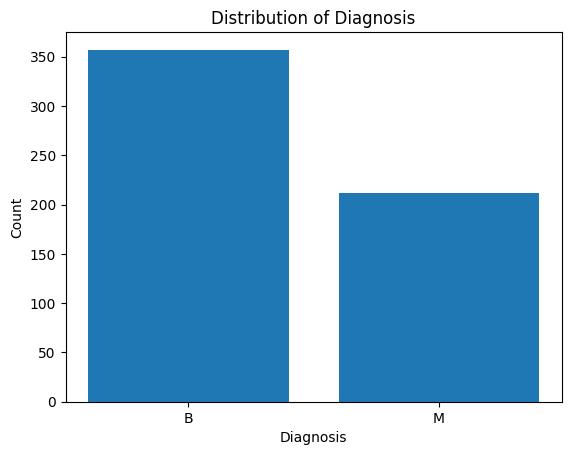

In [4]:
counts = df['diagnosis'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Distribution of Diagnosis')
plt.show()

## 5. Data Partitioning

The target variable `diagnosis` is converted to numbers using a simple rule:  
'M' → 1 (Malignant), 'B' → 0 (Benign)

This is straightforward and avoids using `LabelEncoder`.

The remaining 30 features make up the input matrix `X`.

No scaling is applied. Decision Trees do not need scaling because they split based on thresholds, not distances.

The data is split into 80% training and 20% testing using `random_state=42` for consistency.

The test set is kept separate and only used at the end for final evaluation.

In [5]:

X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Baseline Model — Unpruned Decision Tree

We start with a default `DecisionTreeClassifier` as a baseline.

This creates a fully grown tree with no limits, which usually overfits the training data.

This baseline helps us see the difference between training and test performance.

That gap shows overfitting and explains why we need hyperparameter tuning next.

In [6]:
base = DecisionTreeClassifier(random_state=42)
base.fit(X_train, y_train)

y_pred = base.predict(X_test)

## 7. Baseline Performance Metrics

The classification report shows performance for each class:

- **Precision**: out of predicted Malignant cases, how many are correct  
- **Recall**: out of actual Malignant cases, how many were found  
- **F1-score**: balance between precision and recall  

Model results:

- Accuracy: **0.95**

Class-wise performance:
- **Benign (0)**: precision = 0.96, recall = 0.96  
- **Malignant (1)**: precision = 0.93, recall = 0.93  

Interpretation:

- The model performs well overall with high accuracy.  
- Recall for the Malignant class is **0.93**, meaning most cancer cases are correctly detected.  
- However, about **7% of malignant cases are missed**, which is important in a medical context.  

This suggests the model is strong, but there is still some risk of false negatives.

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 8. Decision Tree Structure — Before Pruning

Visualizing the full tree shows how complex it becomes.

An unpruned tree can grow very deep with many nodes, making it hard to understand.

This gives a baseline to compare with the pruned tree later.

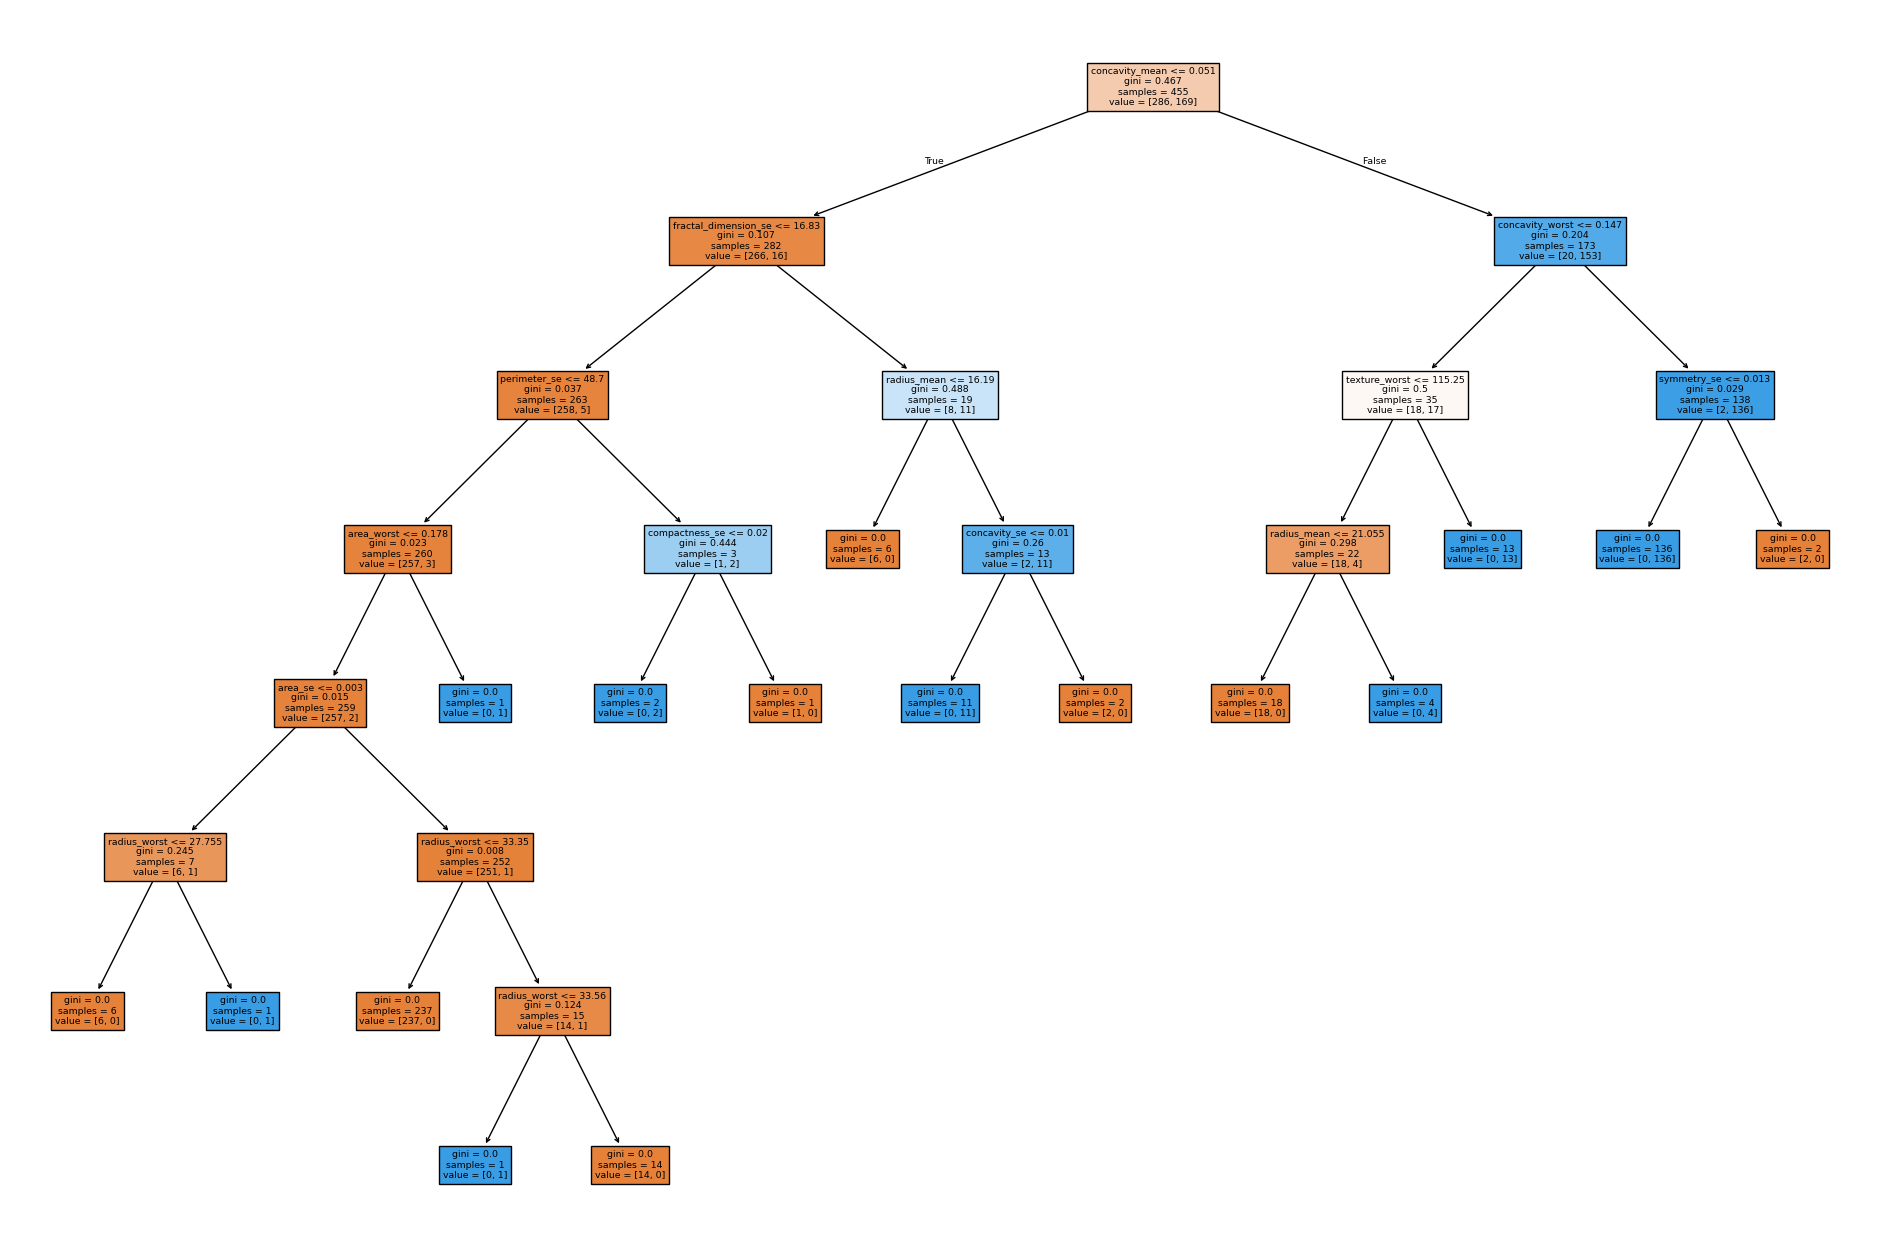

In [8]:
plt.figure(figsize=(24,16))
plot_tree(base, filled=True, feature_names=df.columns.tolist())
plt.show()

## 9. Hyperparameter Optimization via Exhaustive Grid Search

To reduce overfitting, we use **5-fold cross-validation with grid search**.

We tune three main parameters:

| Hyperparameter | Values | Effect |
|---|---|---|
| `max_depth` | 3, 5, 10, None | controls how deep the tree grows |
| `min_samples_split` | 2, 5, 10 | minimum samples needed to split |
| `criterion` | gini, entropy | how split quality is measured |

This gives **24 combinations**, and with 5-fold CV, a total of **120 model fits**.

GridSearchCV picks the best setup based on average accuracy across folds.

`max_depth` is the most important here since limiting depth directly reduces overfitting.

In [9]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_

## 10. Optimal Hyperparameter Configuration

We print the best model found by grid search to see the chosen parameters.

Focus on `max_depth`, it confirms the original tree was overfitting.

The `criterion` (gini or entropy) usually does not change results much, but it can slightly affect which features are chosen first.

In [10]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

## 11. Post-Tuning Performance — Quantifying the Improvement

Compare these results with the baseline model.

- Accuracy improved from **0.95 → 0.96**, showing better overall performance.  
- The model is simpler, so this improvement comes with reduced complexity.  

Class-wise changes:
- **Benign (0)**: recall improved to **1.00** (no benign cases missed)  
- **Malignant (1)**: recall dropped slightly to **0.91**  

Interpretation:

- The model became more conservative in predicting malignant cases.  
- It makes **fewer false positives** (precision = 1.00), but **misses more malignant cases** than before.  

In a medical setting, this trade-off is important:
- Higher precision is good  
- But lower recall for malignant cases is a concern  

This shows that tuning reduced overfitting, but also shifted the balance between precision and recall.

In [11]:
y_pred = best_model.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## 12. Optimized Decision Tree — Interpretability Restored

The tuned tree is much simpler than the original one.

With a limited depth, it becomes easier to read and understand. A domain expert could follow the splits to see why a prediction was made.

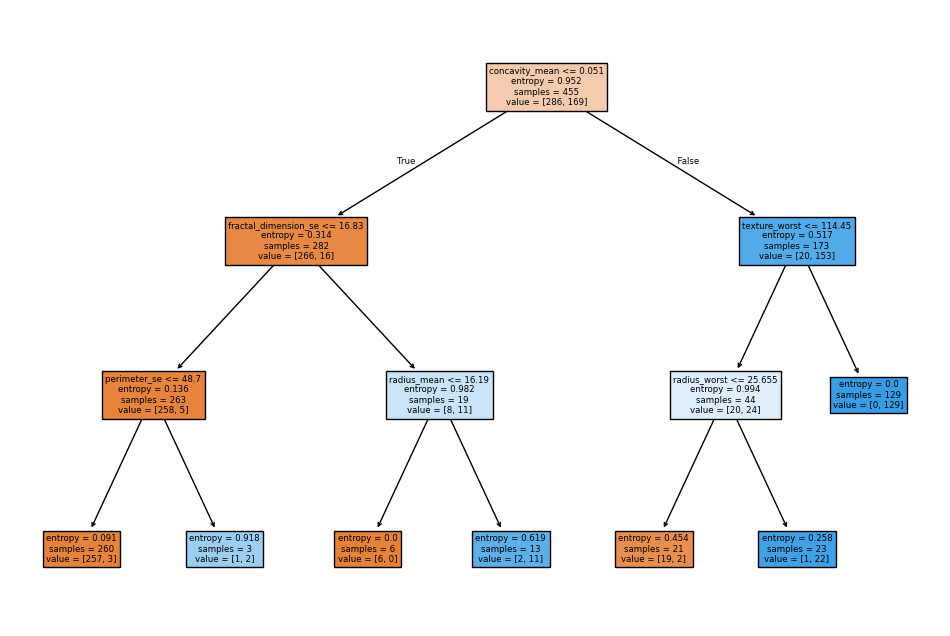

In [13]:
plt.figure(figsize=(12,8))
plot_tree(best_model, filled=True, feature_names=df.columns.tolist())
plt.show()

## 13. Confusion Matrix — Visualizing Error Types

A confusion matrix shows the types of prediction errors.

Results:

- True Negatives (Benign → Benign): **71**  
- False Positives (Benign → Malignant): **0**  
- False Negatives (Malignant → Benign): **4**  
- True Positives (Malignant → Malignant): **39**

Interpretation:

- There are **0 false positives**, so no unnecessary follow-ups.  
- There are **4 false negatives**, meaning 4 malignant cases were missed.  

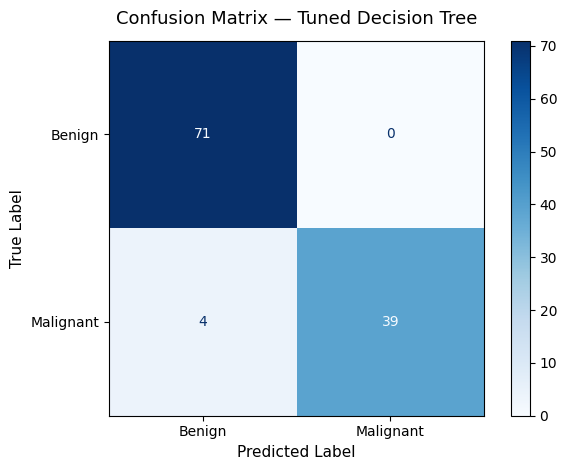

True Negatives  (Benign → Benign):       71
False Positives (Benign → Malignant):    0  ← unnecessary follow-up
False Negatives (Malignant → Benign):    4  ← CRITICAL: missed diagnosis
True Positives  (Malignant → Malignant): 39


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')

plt.title('Confusion Matrix — Tuned Decision Tree', fontsize=13, pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Benign → Benign):       {tn}")
print(f"False Positives (Benign → Malignant):    {fp}  ← unnecessary follow-up")
print(f"False Negatives (Malignant → Benign):    {fn}  ← CRITICAL: missed diagnosis")
print(f"True Positives  (Malignant → Malignant): {tp}")

## 14. Feature Importance Analysis

The Decision Tree assigns importance scores based on how much each feature reduces impurity across splits.

Features used near the top of the tree usually have higher importance.

Top 5 most important features:

- **concave points_mean**: 0.6656  
- **perimeter_worst**: 0.1191  
- **radius_worst**: 0.0894  
- **texture_worst**: 0.0738  
- **texture_mean**: 0.0277  

Interpretation:

- **concave points_mean** dominates by a large margin, meaning it is the most useful feature for splitting the data.  
- Several **"worst" features** also rank high, showing that extreme values are important for diagnosis.  
- The model is relying on a small set of strong features rather than many weak ones.  

This suggests the model is learning meaningful patterns from the data.

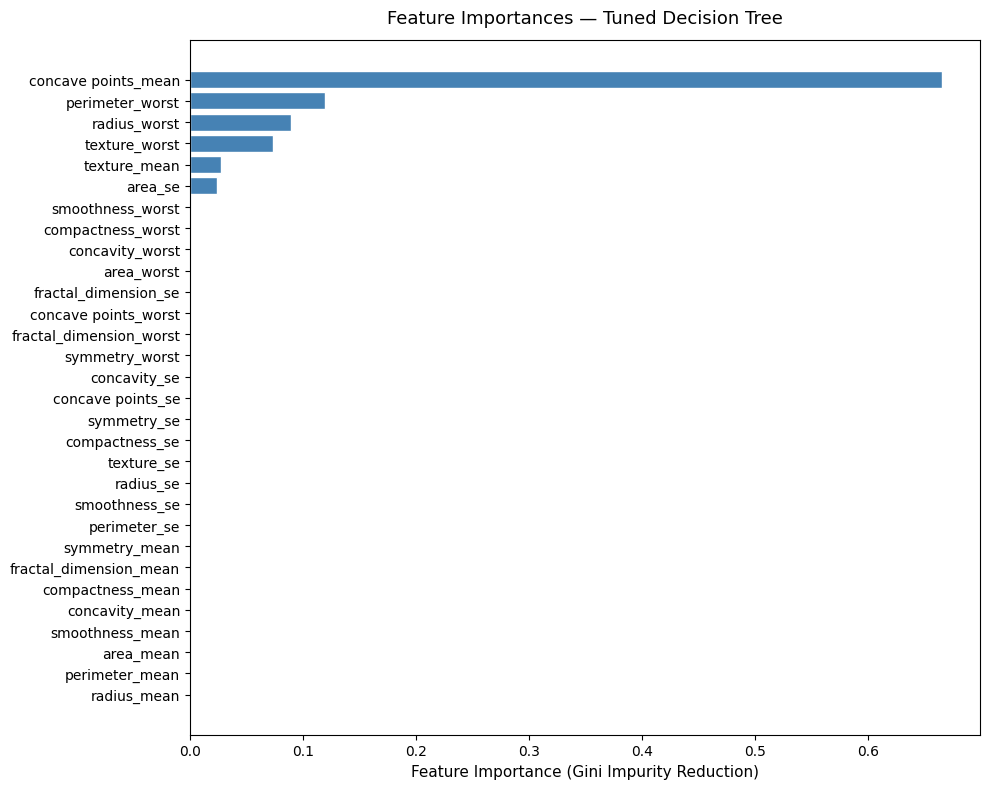

Top 5 most important features:
  concave points_mean            0.6656
  perimeter_worst                0.1191
  radius_worst                   0.0894
  texture_worst                  0.0738
  texture_mean                   0.0277


In [15]:
importances = best_model.feature_importances_
feature_names = X.columns.tolist()

sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=11)
plt.title('Feature Importances — Tuned Decision Tree', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i in sorted_idx[::-1][:5]:
    print(f"  {feature_names[i]:<30} {importances[i]:.4f}")

## Conclusion

This notebook showed how a Decision Tree behaves before and after tuning on a medical classification task.

The baseline model achieved strong accuracy but showed signs of overfitting and an imbalanced trade-off between precision and recall. After tuning, the model became simpler and more reliable, with slightly better accuracy and improved generalization.

However, the tuned model reduced false positives to zero at the cost of slightly lower recall for malignant cases. This highlights an important trade-off: improving overall performance does not always mean improving the most critical metric.

The confusion matrix made it clear that some malignant cases are still missed, which remains a key limitation. Feature importance analysis showed that the model relies heavily on a few meaningful features, especially from the “worst” measurement group, indicating it is learning relevant patterns.

Overall, this experiment demonstrates that controlling tree complexity improves performance and interpretability, but careful attention must still be given to error types, especially in high-stakes domains like medical diagnosis.